## Step 1: Baseline feature and target table

The baselines use engineered features, which already sit in Process.csv (one row per batch). The four targets are in Laboratory.csv. Here I join them, pick the targets, and drop anything that leaks the answer. Output: one clean table for LASSO and XGBoost.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

BASE=Path(r"C:\Users\Arpit Joshua Elias\OneDrive\Desktop\Pharma datasets")
TRAJ=BASE/"Process"

proc=pd.read_csv(BASE/"Process.csv",sep=";")
lab=pd.read_csv(BASE/"Laboratory.csv",sep=";")

print("process",proc.shape)
print("lab",lab.shape)

process (1005, 35)
lab (1005, 55)


In [2]:
df=proc.merge(lab,on="batch",suffixes=("","_lab"))
print("merged",df.shape)
print("batches kept",df["batch"].nunique())

merged (1005, 89)
batches kept 1005


## Pick the four targets

These are the quality attributes the model predicts: dissolution, hardness, weight RSD, tensile strength. I pull them into y and confirm none are missing.

In [3]:
targets=["dissolution_av","tbl_av_hardness","tbl_rsd_weight","fct_tensile"]
y=df[targets].copy()

print("y",y.shape)
print(y.isna().sum())

y (1005, 4)
dissolution_av     0
tbl_av_hardness    0
tbl_rsd_weight     0
fct_tensile        0
dtype: int64


## Drop the leakage, build X

Product identity (code, batch, strength, size) is removed because the audit showed code alone explains most of the hardness variance. Process.csv also carries Drug release columns, which are basically the dissolution answer, so those go too. What remains is the honest engineered feature set.

In [4]:
leak=["batch","code","code_lab","strength","size","start",
      "Drug release average (%)","Drug release min (%)"]

X=proc.drop(columns=[c for c in leak if c in proc.columns]).copy()

print("X",X.shape)
print("X columns:")
print(list(X.columns))

X (1005, 31)
X columns:
['tbl_speed_mean', 'tbl_speed_change', 'tbl_speed_0_duration', 'total_waste', 'startup_waste', 'weekend', 'fom_mean', 'fom_change', 'SREL_startup_mean', 'SREL_production_mean', 'SREL_production_max', 'main_CompForce mean', 'main_CompForce_sd', 'main_CompForce_median', 'pre_CompForce_mean', 'tbl_fill_mean', 'tbl_fill_sd', 'cyl_height_mean', 'stiffness_mean', 'stiffness_max', 'stiffness_min', 'ejection_mean', 'ejection_max', 'ejection_min', 'Startup_tbl_fill_maxDifference', 'Startup_main_CompForce_mean', 'Startup_tbl_fill_mean', 'Residual solvent', 'Total impurities', 'Impurity O', 'Impurity L']


## Encode weekend, final check

weekend is text (no/yes), which the models cannot read, so I map it to 0/1. Then I confirm every feature is numeric and nothing is missing.

In [5]:
X["weekend"]=X["weekend"].map({"no":0,"yes":1}).astype(int)

print("X",X.shape)
print("non-numeric cols:",list(X.select_dtypes(exclude="number").columns))
print("missing values:",int(X.isna().sum().sum()))

X (1005, 31)
non-numeric cols: []
missing values: 72


In [6]:
miss=X.isna().sum()
print(miss[miss>0])

Residual solvent    18
Total impurities    18
Impurity O          18
Impurity L          18
dtype: int64


## Drop the chemistry columns

The only missing values sit in four incoming-material chemistry columns (18 batches each). These are also the only features whose status as a valid input is ambiguous. Dropping them gives a clean process-only feature set: no gaps, no leakage doubt, and it matches the 27 features used in the feasibility test.

In [7]:
chem=["Residual solvent","Total impurities","Impurity O","Impurity L"]
X=X.drop(columns=[c for c in chem if c in X.columns])

print("X",X.shape)
print("missing values:",int(X.isna().sum().sum()))
print(list(X.columns))

X (1005, 27)
missing values: 0
['tbl_speed_mean', 'tbl_speed_change', 'tbl_speed_0_duration', 'total_waste', 'startup_waste', 'weekend', 'fom_mean', 'fom_change', 'SREL_startup_mean', 'SREL_production_mean', 'SREL_production_max', 'main_CompForce mean', 'main_CompForce_sd', 'main_CompForce_median', 'pre_CompForce_mean', 'tbl_fill_mean', 'tbl_fill_sd', 'cyl_height_mean', 'stiffness_mean', 'stiffness_max', 'stiffness_min', 'ejection_mean', 'ejection_max', 'ejection_min', 'Startup_tbl_fill_maxDifference', 'Startup_main_CompForce_mean', 'Startup_tbl_fill_mean']


## Keep code aside for grouping

Product code is not a feature (it leaks), but I need it later to make the leave-one-product-code-out splits. So I store it separately, never inside X.

In [8]:
groups=df["code"].copy()

print("X",X.shape)
print("y",y.shape)
print("groups",groups.shape,"unique codes",groups.nunique())

X (1005, 27)
y (1005, 4)
groups (1005,) unique codes 25


## Step 2: Baseline setup

I build the two baselines from the paper: LASSO and XGBoost. Each predicts all four targets. To keep it honest I cross-validate with GroupKFold on product code, so no product appears in both train and test. I also add a predict-the-mean dummy as the floor the models must beat.

In [9]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor

gkf=GroupKFold(n_splits=5)

print("targets:",targets)
print("features:",X.shape[1])
print("cv: GroupKFold 5 splits on code")

targets: ['dissolution_av', 'tbl_av_hardness', 'tbl_rsd_weight', 'fct_tensile']
features: 27
cv: GroupKFold 5 splits on code


## Train and score the three models

For each target I run the dummy, LASSO and XGBoost through the 5 grouped folds and record RMSE on the held-out fold. LASSO needs scaling so it goes in a pipeline. The dummy is the floor: any real model must beat it.

In [10]:
import warnings
warnings.filterwarnings("ignore")

models={
"dummy":DummyRegressor(strategy="mean"),
"lasso":Pipeline([("sc",StandardScaler()),("m",Lasso(alpha=0.1,max_iter=10000))]),
"xgb":XGBRegressor(n_estimators=300,max_depth=4,learning_rate=0.05,random_state=42,verbosity=0)
}

results={}
for tgt in targets:
    yt=y[tgt].values
    results[tgt]={}
    for name,model in models.items():
        rmses=[]
        for tr,te in gkf.split(X,yt,groups=groups):
            model.fit(X.iloc[tr],yt[tr])
            pred=model.predict(X.iloc[te])
            rmses.append(np.sqrt(mean_squared_error(yt[te],pred)))
        results[tgt][name]=np.mean(rmses)
    print(tgt,"done")

print("all targets done")

dissolution_av done
tbl_av_hardness done
tbl_rsd_weight done
fct_tensile done
all targets done


## Results table: model vs baseline

I put the RMSE for all three models side by side, one row per target. Lower is better. The check is simple: LASSO and XGBoost should both beat the dummy.

In [11]:
table=pd.DataFrame(results).T
table=table[["dummy","lasso","xgb"]]
table=table.round(3)

print(table)

                  dummy  lasso    xgb
dissolution_av    3.512  3.119  3.147
tbl_av_hardness  11.439  6.619  5.004
tbl_rsd_weight    0.558  0.538  0.605
fct_tensile       0.419  0.343  0.255


## Save the results table

I write the comparison table to CSV so it can go into the report and the weekly deliverable.

In [12]:
table.to_csv(BASE/"baseline_results.csv")
print("saved to",BASE/"baseline_results.csv")
print(table)

saved to C:\Users\Arpit Joshua Elias\OneDrive\Desktop\Pharma datasets\baseline_results.csv
                  dummy  lasso    xgb
dissolution_av    3.512  3.119  3.147
tbl_av_hardness  11.439  6.619  5.004
tbl_rsd_weight    0.558  0.538  0.605
fct_tensile       0.419  0.343  0.255


## Step 3: Tuned baselines with nested CV

The first baselines used guessed settings. Here I tune them properly. The outer GroupKFold tests on unseen products. Inside each fold, an inner GroupKFold picks the best settings using only the training products. This gives each baseline its fair best shot, so any later comparison against the deep model is honest.

In [13]:
from sklearn.model_selection import GridSearchCV

inner=GroupKFold(n_splits=4)
outer=GroupKFold(n_splits=5)

lasso_grid={"m__alpha":[0.01,0.05,0.1,0.5,1.0]}
xgb_grid={"n_estimators":[200,400],"max_depth":[3,4,6],"learning_rate":[0.03,0.1]}

print("inner: GroupKFold 4 | outer: GroupKFold 5")
print("lasso settings tried:",len(lasso_grid["m__alpha"]))
print("xgb settings tried:",2*3*2)

inner: GroupKFold 4 | outer: GroupKFold 5
lasso settings tried: 5
xgb settings tried: 12


## Run the tuned baselines

For each target I run nested CV. The inner loop picks the best settings, the tuned model is scored on the unseen products, and I average the RMSE across the outer folds. This takes longer than the first pass because it trains many models.

In [14]:
tuned={}
for tgt in targets:
    yt=y[tgt].values
    tuned[tgt]={}
    for name in ["lasso","xgb"]:
        rmses=[]
        for tr,te in outer.split(X,yt,groups=groups):
            Xtr,Xte=X.iloc[tr],X.iloc[te]
            ytr,yte=yt[tr],yt[te]
            gtr=groups.iloc[tr]
            if name=="lasso":
                base=Pipeline([("sc",StandardScaler()),("m",Lasso(max_iter=10000))])
                grid=lasso_grid
            else:
                base=XGBRegressor(random_state=42,verbosity=0)
                grid=xgb_grid
            search=GridSearchCV(base,grid,cv=inner.split(Xtr,ytr,groups=gtr),
                                scoring="neg_root_mean_squared_error")
            search.fit(Xtr,ytr)
            pred=search.best_estimator_.predict(Xte)
            rmses.append(np.sqrt(mean_squared_error(yte,pred)))
        tuned[tgt][name]=np.mean(rmses)
    print(tgt,"done")

print("all targets done")

dissolution_av done
tbl_av_hardness done
tbl_rsd_weight done
fct_tensile done
all targets done


## Tuned vs first-pass results

I put the tuned RMSE next to the first-pass numbers. Lower is better. This shows whether proper tuning gave the baselines a meaningful lift, which matters because the deep model will have to beat the tuned version, not the weak one.

In [15]:
tuned_table=pd.DataFrame(tuned).T[["lasso","xgb"]].round(3)
tuned_table.columns=["lasso_tuned","xgb_tuned"]

compare=table.join(tuned_table)
print(compare)

                  dummy  lasso    xgb  lasso_tuned  xgb_tuned
dissolution_av    3.512  3.119  3.147        3.102      3.010
tbl_av_hardness  11.439  6.619  5.004        6.658      5.108
tbl_rsd_weight    0.558  0.538  0.605        0.526      0.570
fct_tensile       0.419  0.343  0.255        0.332      0.256


In [16]:
compare.to_csv(BASE/"baseline_results_tuned.csv")
print("saved to",BASE/"baseline_results_tuned.csv")
print(compare)

saved to C:\Users\Arpit Joshua Elias\OneDrive\Desktop\Pharma datasets\baseline_results_tuned.csv
                  dummy  lasso    xgb  lasso_tuned  xgb_tuned
dissolution_av    3.512  3.119  3.147        3.102      3.010
tbl_av_hardness  11.439  6.619  5.004        6.658      5.108
tbl_rsd_weight    0.558  0.538  0.605        0.526      0.570
fct_tensile       0.419  0.343  0.255        0.332      0.256


## Step 4: All evaluation metrics

The mentor asked for all evaluation metrics, not just RMSE. Here I report three: RMSE and MAE (error size, lower is better) and R squared (variation explained, higher is better). I compute them for every model and target under the same grouped CV so the comparison stays fair.

In [17]:
from sklearn.metrics import mean_absolute_error,r2_score

def score_model(model,Xd,yd,grp):
    rmse,mae,r2=[],[],[]
    for tr,te in gkf.split(Xd,yd,groups=grp):
        model.fit(Xd.iloc[tr],yd[tr])
        pred=model.predict(Xd.iloc[te])
        rmse.append(np.sqrt(mean_squared_error(yd[te],pred)))
        mae.append(mean_absolute_error(yd[te],pred))
        r2.append(r2_score(yd[te],pred))
    return np.mean(rmse),np.mean(mae),np.mean(r2)

allmetrics=[]
for tgt in targets:
    yt=y[tgt].values
    for name,model in models.items():
        rm,ma,r2=score_model(model,X,yt,groups)
        allmetrics.append({"target":tgt,"model":name,
                           "RMSE":round(rm,3),"MAE":round(ma,3),"R2":round(r2,3)})

metrics_table=pd.DataFrame(allmetrics)
print(metrics_table.to_string(index=False))

         target model   RMSE   MAE     R2
 dissolution_av dummy  3.512 2.836 -0.329
 dissolution_av lasso  3.119 2.416 -0.062
 dissolution_av   xgb  3.147 2.479 -0.077
tbl_av_hardness dummy 11.439 8.150 -0.347
tbl_av_hardness lasso  6.619 5.290  0.127
tbl_av_hardness   xgb  5.004 3.844  0.525
 tbl_rsd_weight dummy  0.558 0.301 -0.020
 tbl_rsd_weight lasso  0.538 0.267  0.059
 tbl_rsd_weight   xgb  0.605 0.297 -0.299
    fct_tensile dummy  0.419 0.381 -2.674
    fct_tensile lasso  0.343 0.288 -1.494
    fct_tensile   xgb  0.255 0.197 -0.319


In [18]:
metrics_table.to_csv(BASE/"baseline_metrics_all.csv",index=False)
print("saved to",BASE/"baseline_metrics_all.csv")

saved to C:\Users\Arpit Joshua Elias\OneDrive\Desktop\Pharma datasets\baseline_metrics_all.csv


## Step 5: Full comparison table (baselines vs MT-TrajNet)

I bring the MT-TrajNet results (from the GPU notebook) alongside the baselines so all models can be compared per target in one place. MT-TrajNet RMSE is the mean across the three GroupKFold folds.

In [19]:
mttrajnet={
"dissolution_av":3.703,
"tbl_av_hardness":7.598,
"tbl_rsd_weight":0.554,
"fct_tensile":0.349
}

comparison=table.copy()   
comparison["MT_TrajNet"]=[mttrajnet[t] for t in comparison.index]
comparison=comparison.round(3)

print("FULL COMPARISON: baselines vs MT-TrajNet (RMSE, lower is better)")
print(comparison)

comparison.to_csv(r"C:\Users\Arpit Joshua Elias\OneDrive\Desktop\Pharma datasets\full_comparison.csv")
print("\nsaved full_comparison.csv")

FULL COMPARISON: baselines vs MT-TrajNet (RMSE, lower is better)
                  dummy  lasso    xgb  MT_TrajNet
dissolution_av    3.512  3.119  3.147       3.703
tbl_av_hardness  11.439  6.619  5.004       7.598
tbl_rsd_weight    0.558  0.538  0.605       0.554
fct_tensile       0.419  0.343  0.255       0.349

saved full_comparison.csv


## Step 5: Full comparison table (all baselines vs MT-TrajNet)

I bring the MT-TrajNet results alongside all the baselines, including the tuned versions, so the comparison is against the strongest baseline per target. MT-TrajNet RMSE is the mean across the three GroupKFold folds.

In [20]:
mttrajnet={
"dissolution_av":3.703,
"tbl_av_hardness":7.598,
"tbl_rsd_weight":0.554,
"fct_tensile":0.349
}

comparison=compare.copy()   
comparison["MT_TrajNet"]=[mttrajnet[t] for t in comparison.index]

basecols=[c for c in comparison.columns if c not in ["dummy","MT_TrajNet"]]
comparison["best_baseline"]=comparison[basecols].min(axis=1)
comparison=comparison.round(3)

print("FULL COMPARISON: all baselines vs MT-TrajNet (RMSE, lower is better)")
print(comparison)

comparison.to_csv(r"C:\Users\Arpit Joshua Elias\OneDrive\Desktop\Pharma datasets\full_comparison.csv")
print("\nsaved full_comparison.csv")

FULL COMPARISON: all baselines vs MT-TrajNet (RMSE, lower is better)
                  dummy  lasso    xgb  lasso_tuned  xgb_tuned  MT_TrajNet  \
dissolution_av    3.512  3.119  3.147        3.102      3.010       3.703   
tbl_av_hardness  11.439  6.619  5.004        6.658      5.108       7.598   
tbl_rsd_weight    0.558  0.538  0.605        0.526      0.570       0.554   
fct_tensile       0.419  0.343  0.255        0.332      0.256       0.349   

                 best_baseline  
dissolution_av           3.010  
tbl_av_hardness          5.004  
tbl_rsd_weight           0.526  
fct_tensile              0.255  

saved full_comparison.csv


## Hardness target distribution

Hardness has the highest and most variable RMSE across all models. I look at its distribution to understand why: high variance, skew, or spread across product codes would all make it harder to predict and explain the larger errors.

hardness stats:
  mean: 54.87
  std: 12.67
  min: 27 max: 102
  coefficient of variation: 0.231

coefficient of variation, all targets:
  dissolution_av: 0.037
  tbl_av_hardness: 0.231
  tbl_rsd_weight: 0.525
  fct_tensile: 0.223


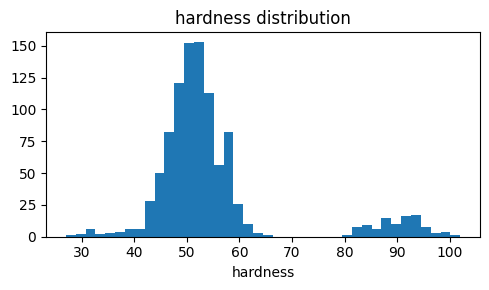

In [22]:
import matplotlib.pyplot as plt
import pandas as pd

h=y["tbl_av_hardness"].values
print("hardness stats:")
print("  mean:",round(h.mean(),2))
print("  std:",round(h.std(),2))
print("  min:",round(h.min(),2),"max:",round(h.max(),2))
print("  coefficient of variation:",round(h.std()/h.mean(),3))

# compare CV across all four targets for context
print("\ncoefficient of variation, all targets:")
for t in ["dissolution_av","tbl_av_hardness","tbl_rsd_weight","fct_tensile"]:
    v=y[t].values
    print(f"  {t}: {round(v.std()/v.mean(),3)}")

plt.figure(figsize=(5,3))
plt.hist(h,bins=40); plt.title("hardness distribution"); plt.xlabel("hardness")
plt.tight_layout(); plt.show()